# Семинар 3,4 - Базовая визуализация. Группировка

## Считываем данные

In [ ]:
import pandas as pd
data = pd.read_csv('https://raw.githubusercontent.com/aaparshina/FCI_22-23_data_analysis/main/data/titanic.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Описание признаков:

**PassengerId** - id пассажира

**Survived** выжил пассажирил (1) или нет (0)

**Pclass** - класс пассажира

**Name** - имя пассажира

**Sex** - пол пассажира

**Age** - возраст пассажира

**SibSp** - количество родственников (братьев, сестер, супругов) пассажира на борту

**Parch** - количество родственников (родителей / детей) пассажира на борту

**Ticket** - номер билета

**Fare** - тариф (стоимость билета)

**Cabin** - номер кабины

**Embarked** - порт, в котором пассажир сел на борт (C - Cherbourg, S - Southampton, Q = Queenstown)

## **Частотная таблица** `.value_counts()`

- Строится как правило, по категориальным данным
- Показывает, то сколько раз каждая уникальная категория встретилась в признаке

```
датафрейм['столбец'].value_counts()

```

In [ ]:
data['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


- Тип данных, который возращает этот метод называется `Series object`:
- В `Series object` всего два столбца: первый столбец индексов (`.index`), второй значения (`.values`)

In [ ]:
data['Pclass'].value_counts().index # выводим индексы (категории)

Index([3, 1, 2], dtype='int64', name='Pclass')

In [ ]:
data['Pclass'].value_counts().values # выводим значения (частоты)

array([491, 216, 184])

- `.value_counts()` автоматически сортирует категории от самой часто до самой редкой. *Например: больше всего пассажиров ехало первым классом и таких пассажиров было 491*

- Если вы хотите отсортировать категории, наоборот, от самой редкой, до самой частой воспользуйтесь`.sort_values()`

```
датафрейм['столбец'].value_counts().sort_values()
```

- Если вы хотите отсортировать частотную таблицу по категориям (первым столбец) можно воспользоваться методом `.sort_index()`
  - по возрастанию категорий (A-Z, от 0 до N)
  ```
датафрейм['столбец'].value_counts().sort_index()
```
  - по убыванию категорий (Z-A, от N до 0)
  ```
датафрейм['столбец'].value_counts().sort_index(ascending = False)
```

In [ ]:
data['Pclass'].value_counts().sort_values() #сортируем по ВОЗРАСТАНИЮ частотности

,count
Pclass,
2,184
1,216
3,491


In [ ]:
data['Pclass'].value_counts().sort_index() #сортируем по ВОЗРАСТАНИЮ категории (от 1 до 3)

,count
Pclass,
1,216
2,184
3,491


In [ ]:
data['Pclass'].value_counts().sort_index(ascending = False) #сортируем по УБЫВАНИЮ категории (от 3 до 1)

,count
Pclass,
3,491
2,184
1,216


+ Данные в частотной таблице можно привести к долям с помощью параметра `normalize = True`:
```
датафреймх['столбец'].value_counts(normalize = True)
```

In [ ]:
data['Pclass'].value_counts(normalize = True)

,proportion
Pclass,
3,0.551066
1,0.242424
2,0.206510


##  **Базовая визуализация** `.plot()`

### Линейная диаграмма

```
датафрейм['столбец'].value_counts().plot()
```
- Используется для **категориальных** данных
- Используется чтобы показать динамику в течении времени (но у нас в данных временных данных)

In [ ]:
data['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


<Axes: xlabel='Embarked'>

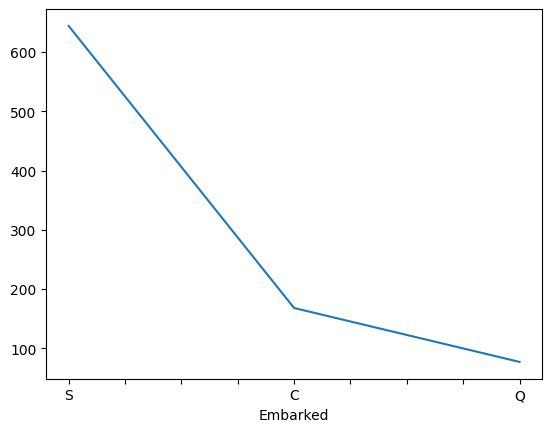

In [ ]:
data["Embarked"].value_counts().plot()

### Столбчатая диаграмма

In [ ]:
data["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


```
датафрейм['столбец'].value_counts().plot(kind = 'bar')
```
- Используется для **категориальных** данных

<Axes: xlabel='Pclass'>

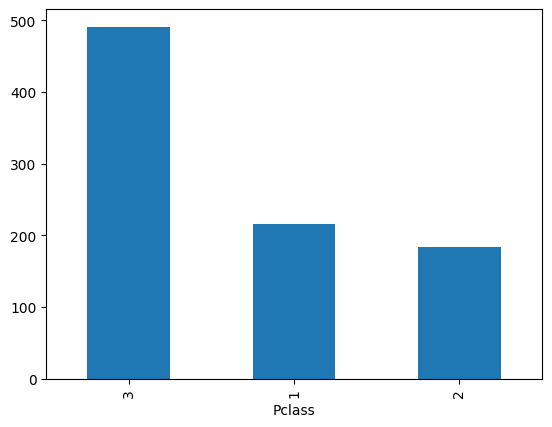

In [ ]:
data["Pclass"].value_counts().plot(kind = 'bar')

<Axes: xlabel='Pclass'>

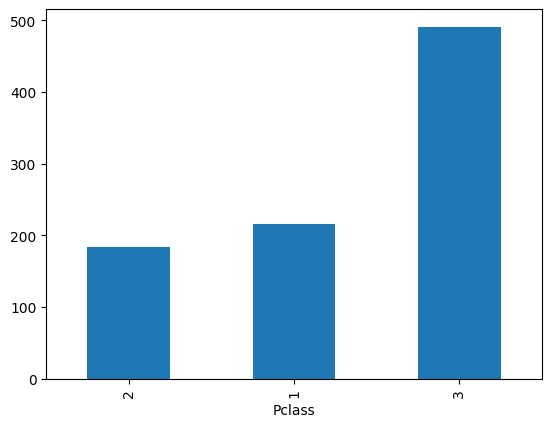

In [ ]:
data["Pclass"].value_counts().sort_values().plot(kind = 'bar')

<Axes: xlabel='Pclass'>

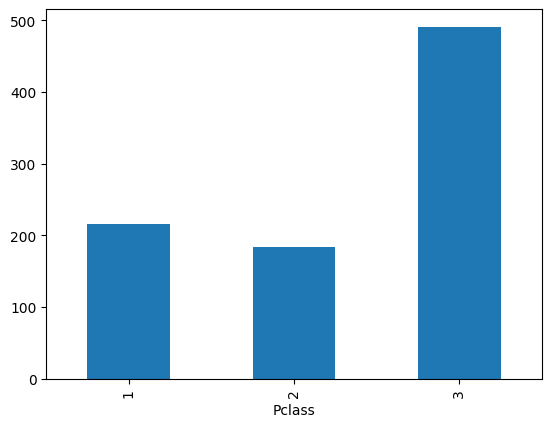

In [ ]:
data["Pclass"].value_counts().sort_index().plot(kind = 'bar')

<Axes: xlabel='Pclass'>

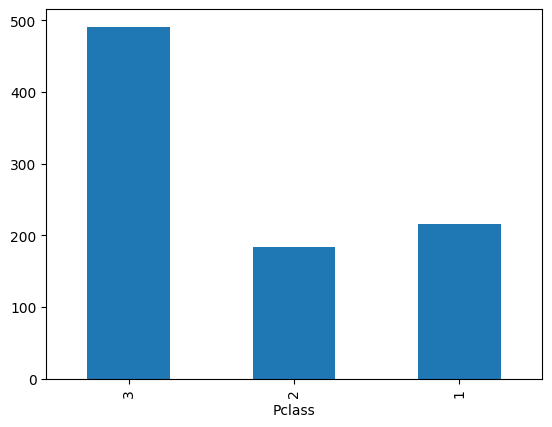

In [ ]:
data["Pclass"].value_counts().sort_index(ascending = False).plot(kind = 'bar')

### Круговая диаграмма

```
датафрейм['столбец'].value_counts().plot(kind = 'pie')
```
- Используется для **категориальных** данных

<Axes: ylabel='count'>

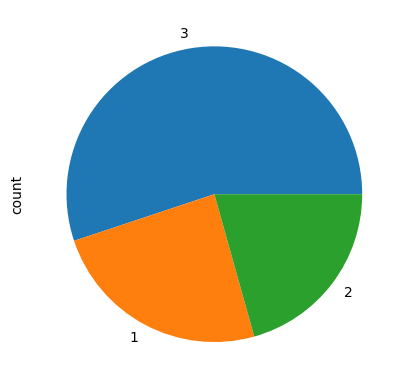

In [ ]:
data["Pclass"].value_counts().plot(kind = 'pie')

### Гистограмма распределения

```
датафрейм['столбец'].plot(kind = 'hist')
```


- Используется для **числовых** данных
- По **горизонтальной** оси *значение признака*, по **вертикальной** *частота*
- Используется чтобы показать распределение данных

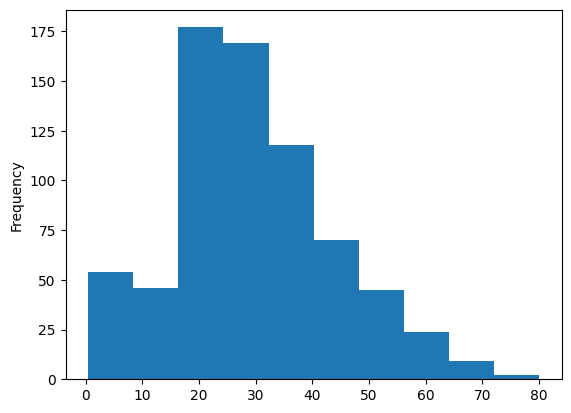

In [ ]:
data['Age'].plot(kind='hist')

### Ящик с усами

```
датафрейм['столбец'].plot(kind = 'box', vert = False)
```
- Используется для **числовых** данных
- По **горизонтальной** оси *значение признака*
- Что значит эта коробка разберем на семинаре с описательными статистиками

<Axes: >

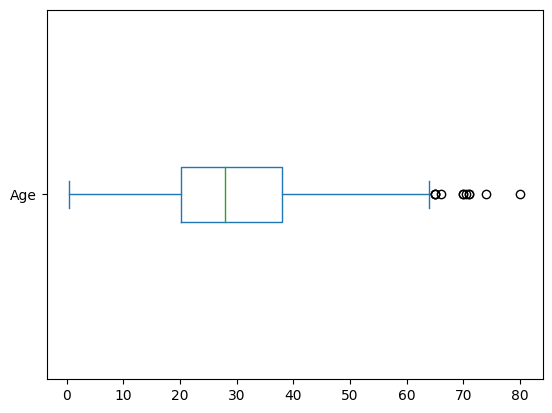

In [ ]:
data['Age'].plot(kind='box', vert = False) #vert = False делает её горизонтальной

### Диаграмма рассеяния

```
датафрейм.plot('столбец X', 'столбец Y', kind = 'scatter')
```
- Используется для **числовых** данных
- Используется, чтобы показать зависимость между числовыми признаками

<Axes: xlabel='Age', ylabel='Fare'>

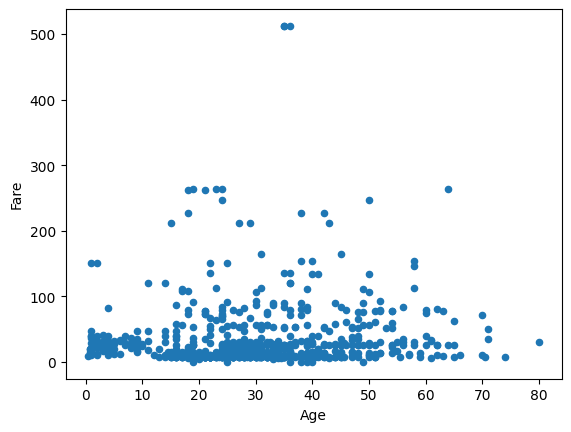

In [ ]:
data.plot('Age', 'Fare', kind = 'scatter')

Описание признаков:

**PassengerId** - id пассажира

**Survived** бинарная переменная: выжил пассажирил (1) или нет (0)

**Pclass** - класс пассажира

**Name** - имя пассажира

**Sex** - пол пассажира

**Age** - возраст пассажира

**SibSp** - количество родственников (братьев, сестер, супругов) пассажира на борту

**Parch** - количество родственников (родителей / детей) пассажира на борту

**Ticket** - номер билета

**Fare** - тариф (стоимость билета)

**Cabin** - номер кабины

**Embarked** - порт, в котором пассажир сел на борт (C - Cherbourg, S - Southampton, Q = Queenstown)

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/aaparshina/FCI_22-23_data_analysis/main/data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## A1

Для какого из следующих наборов данных гистограмма была бы наиболее подходящим видом визуализации?

Выберите один ответ:

+ Количество книг, прочитанных каждым учеником в классе.

+ Доли возрастных категорий (18-25, 25-40, 40+ лет) внутри кружка по чтению современной литературы.


+ Среднесуточная температура в течение года.


+ Динамика продаж продукта в разных странах в течение определенного периода времени.

## A8

Какой переменной может соответствовать гистограмма, приведённая на рисунке ниже?
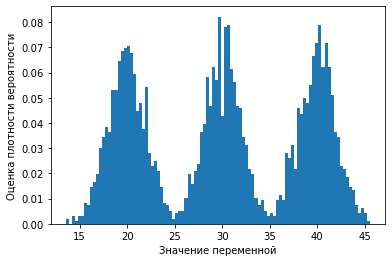

+ Количество рабочих часов в день взрослых людей в возрасте от 18 до 40 лет.


+ Количество видимых невооружённым глазом созвездий в разное время суток.


+ Количество рабочих часов в неделю работающих взрослых людей в возрасте от 20 до 40 лет.


+ Количество детей в российских семьях в 2008 году.

## **Библиотека ```matplotlib```**

Базовая библиотека для визуализации

In [ ]:
import matplotlib.pyplot as plt

### Основные графики

Гистограмма

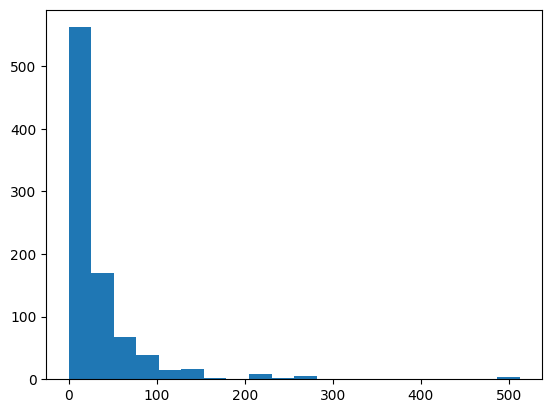

In [ ]:
plt.hist(df['Fare'])#, bins = 20);

Ящик с усами

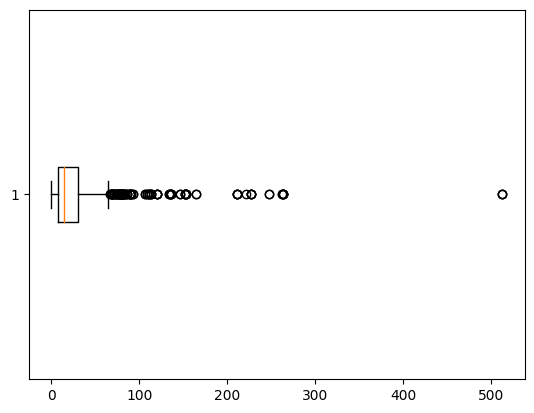

In [ ]:
plt.boxplot(df['Fare'], vert = False);

Столбчатая диаграмма

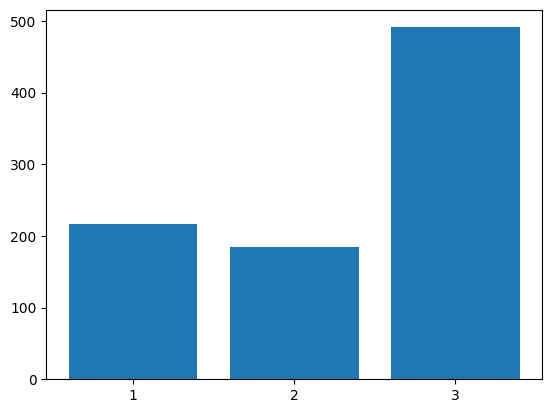

In [ ]:
fr_table = df['Pclass'].value_counts() #Series object
plt.bar(fr_table.index, fr_table.values) #ось x, ось y
plt.xticks([1, 2, 3]); # изменяем шаг делений на оси X

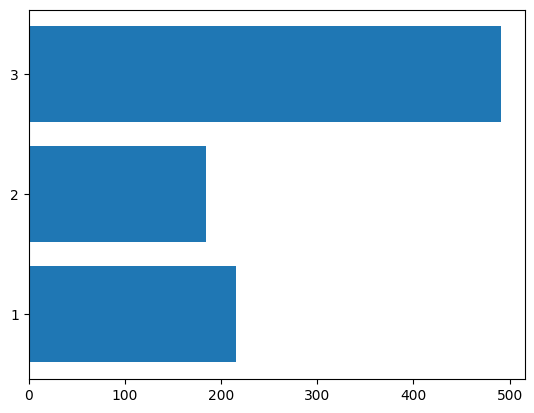

In [ ]:
fr_table = df['Pclass'].value_counts()
plt.barh(fr_table.index, fr_table.values) #ось y, ось x
plt.yticks([1, 2, 3]);  # изменяем шаг делений на оси Y

Круговая диграмма:

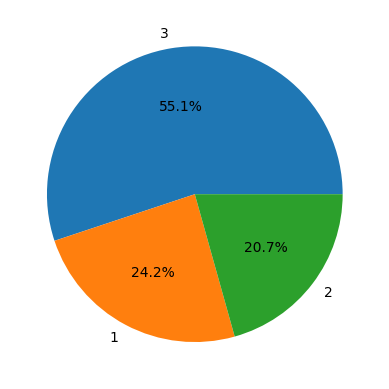

In [ ]:
fr_table = df['Pclass'].value_counts()
plt.pie(fr_table.values,
        labels = fr_table.index,
        autopct='%1.1f%%'); #подписии долей

Линейный график:

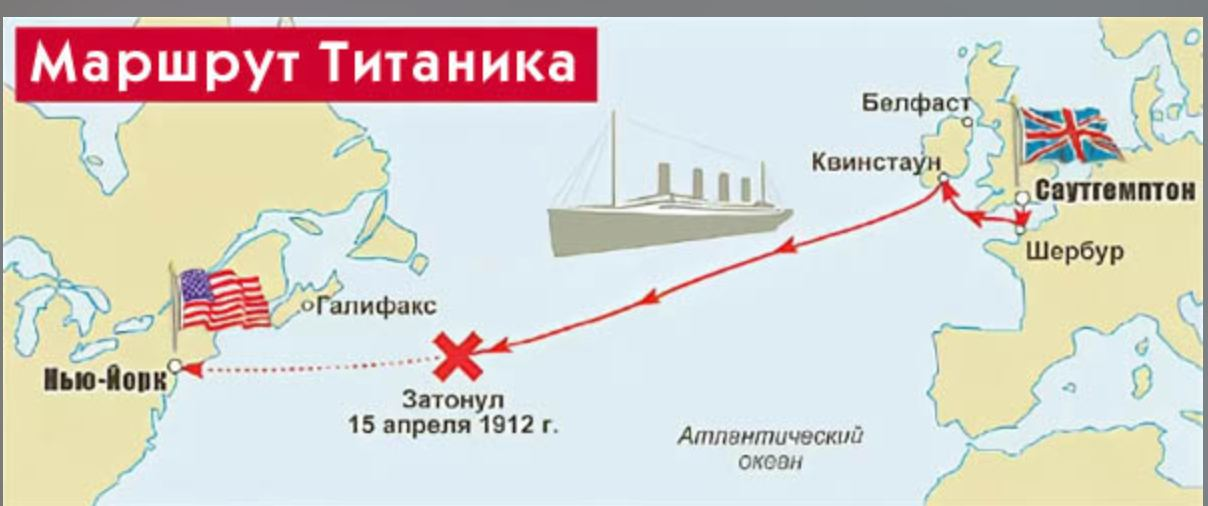

C (Cherbourg) -> S (Southampton) -> Q (Queenstown)

In [ ]:
fr_table = df['Embarked'].value_counts()
fr_table

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
ports = ['Cherbourg', 'Southampton', 'Queenstown']

In [ ]:
[fr_table[p[0]] for p in ports]

[168, 644, 77]

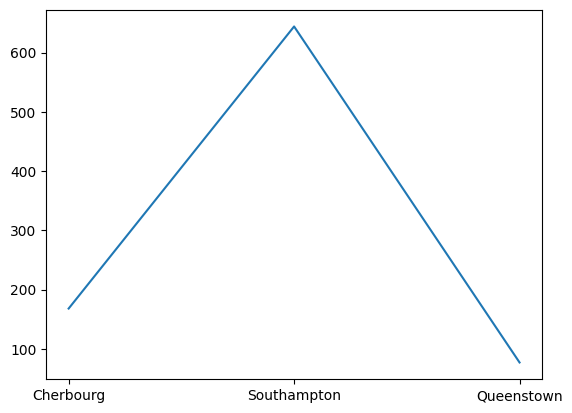

In [ ]:
fr_table = df['Embarked'].value_counts()
plt.plot(ports, #ось X
         [168, 644, 77]); #ось Y

### Базовое оформление

#### Заголовок

Text(0.5, 1.0, 'Гистограмма распределения цены')

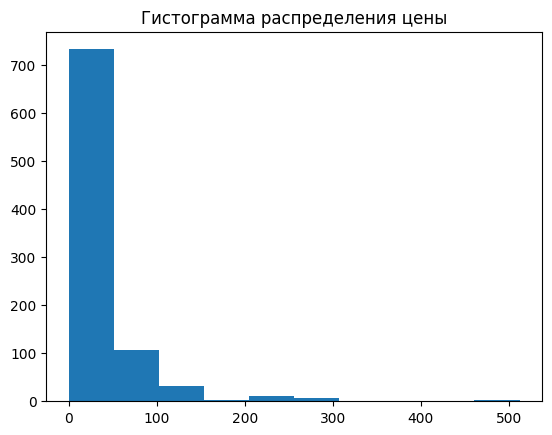

In [ ]:
plt.hist(df['Fare']) #график
plt.title('Гистограмма распределения цены') #заголовок

#### Подписи осей

Text(0, 0.5, 'Частота')

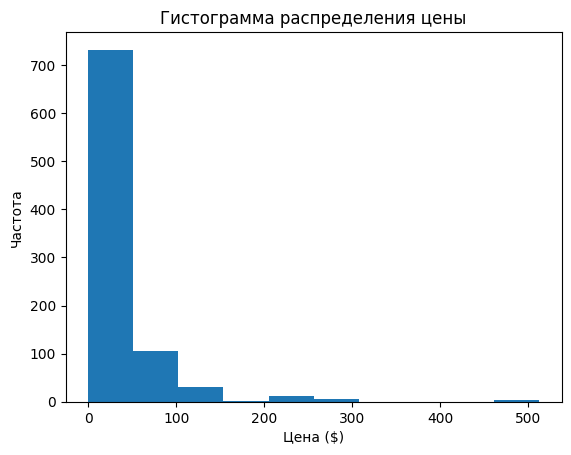

In [ ]:
plt.hist(df['Fare']) #график
plt.title('Гистограмма распределения цены') #заголовок
plt.xlabel('Цена ($)') #подпись оси X
plt.ylabel('Частота') #подпись оси Y

#### Цвет

Text(0, 0.5, 'Частота')

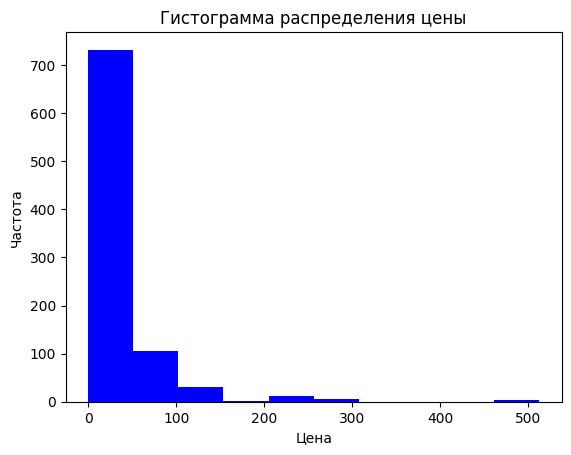

In [ ]:
plt.hist(df['Fare'], color = '#44944A'); #график
plt.title('Гистограмма распределения цены') #заголовок
plt.xlabel('Цена') #подпись оси X
plt.ylabel('Частота') #подпись оси X

## **Выборка VS Генеральная совокупность**

<hr>

*Вспомним определения из онлайн-курса:*

**Генеральная совокупность** — это совокупность всех объектов, которые представляют интерес в конкретном исследовании.

**Выборка** — это группа объектов, отобранных из генеральной совокупности для исследования.

**Репрезентативность** — соответствие характеристик выборки характеристикам генеральной совокупности.

<hr>

## A5

Отважная исследовательница Анастасия занимается исследованием гигантских кальмаров (giant squids). Какая из собранных ей выборок будет более репрезентативной, чем другие?

Выберите один ответ:

+ Данные о кальмарах, собранные в течение всего года по всем местам обитания.


+ Данные о кальмарах, обитающих вблизи подводных вулканов.


+ Данные о всех видах кальмаров во время осеннего сезона.


+ Данные, собираемые в течение года,  о кальмарах, обитающих в наиболее экологически чистых регионах.

## **Методы агрегирования данных**

**Функция агрегирования** - это метод, который принимает несколько отдельных значений и возвращает сводные данные.

### `.mean()`

In [ ]:
df['Fare'].mean() #среднее

32.204207968574636

### `.sum()`

In [ ]:
df['Fare'].sum() #сумма

28693.9493

### `.min()` and `.max()`

In [ ]:
df['Fare'].min()

0.0

In [ ]:
df['Fare'].max()

512.3292

### `.count()`

In [ ]:
df['Cabin'].count() #количество не пропущенных значения в столбце

204

### `.unique()`

In [ ]:
df['Pclass'].unique() #массив уникальных значений из столбца

array([3, 1, 2])

### `.nunique()`

In [ ]:
df['Pclass'].nunique() #количество уникальных значений в столбце

3

In [ ]:
Cabin
123
234
123
123
456
111

array([123, 234, 456, 111]) #.unique()
4 #.nunique()

## **Группировка данных** `.groupby()`

### Простейшая группировка


``` python
датафрейм.groupby("столбец группировки")["столбец интереса"].метод агрегирования()
```

Столбец группировки:
- Категориальные переменные

Столбец интереса:
- Количественные переменные
- Категориальные переменные

Найдем среднюю цену за билет в разных портах:

In [ ]:
df.groupby("Embarked")["Fare"].mean()

,Fare
Embarked,
C,59.954144
Q,13.276030
S,27.079812


### Несколько столбцов интереса

``` python
датафрейм.groupby("столбец группировки")[["ст. интереса 1", "ст. интереса 2", ...]].метод агрегирования()
```

Найдем среднюю цену за билет и среднй возраст людей в разных портах:

In [ ]:
df.groupby('Embarked')[['Fare', 'Age']].mean()

,Fare,Age
Embarked,,
C,59.954144,30.814769
Q,13.276030,28.089286
S,27.079812,29.445397


### Несколько методов агрегирования

``` python
датафрейм.groupby("ст. группировки")["ст. интереса"].agg(["метод 1", "метод 2", ...])
```

In [ ]:
df.groupby("Embarked")["Fare"].agg(['mean', 'sum'])

,mean,sum
Embarked,,
C,59.954144,10072.2962
Q,13.276030,1022.2543
S,27.079812,17439.3988


### Несколько столбцов группировки

In [ ]:
data.groupby(['Embarked', 'Sex'])['Fare'].mean()

Embarked  Sex   
C         female    75.169805
          male      48.262109
Q         female    12.634958
          male      13.838922
S         female    38.740929
          male      21.711996
Name: Fare, dtype: float64

## **Метод `.merge()`**

Для объединения двух датафреймов по общему ключу мы можем использовать метод
`merge()`. Посмотрим, как это работает:

``` pd.merge(датафрейм1, датафрейм2, ...) ```

``` датафрейм1.merge(датафрейм2, ...) ```

### Параметр `how`

#### `how = 'inner'`

Мы берем ключи из двух датафреймов и оставляем в соединенном только те, которые присутствуют в обоих одновременно:



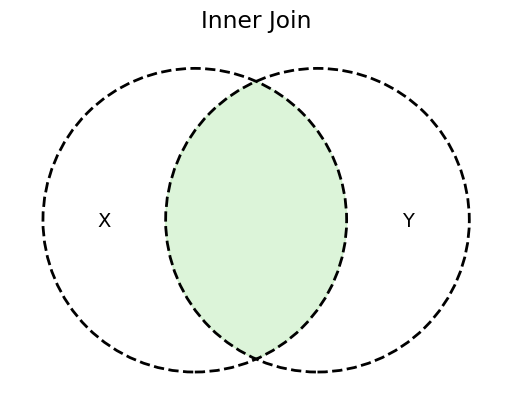

In [ ]:
# @title

#import module
from matplotlib_venn import venn2, venn2_circles
from matplotlib import pyplot as plt

plt.rcParams['font.size'] = '14'

# depict venn diagram
v = venn2(subsets=(1, 1, 1),
          set_labels=('', ''))


# set color to defined path id
v.get_patch_by_id("100").set_color("white")
v.get_patch_by_id("010").set_color("white")
v.get_patch_by_id("11").set_color("#a8e4a0")
# set text to defined label id "A"
# v.get_label_by_id('A').set_text('A new')

v.get_label_by_id("100").set_text("X")
v.get_label_by_id("010").set_text("Y")
v.get_label_by_id("11").set_text("")

# add outline
venn2_circles(subsets=(1, 1, 1),
              linestyle="dashed", linewidth=2)

# assign title
plt.title("Inner Join")
plt.show()




In [ ]:
df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                    'B': ['B0', 'B1', 'B2']},
                     index=['K0', 'K1', 'K2'])

df2 = pd.DataFrame({'C': ['C0', 'C2', 'C3'],
                    'D': ['D0', 'D2', 'D3']},
                     index=['K0', 'K2', 'K3'])
display(df1, df2)

,A,B
K0,A0,B0
K1,A1,B1
K2,A2,B2


,C,D
K0,C0,D0
K2,C2,D2
K3,C3,D3


In [ ]:
result_inner = pd.merge(df1, df2, left_index=True, right_index=True)
result_inner # значение inner стоит по умолчанию в аргументе `how`, так что в этом случае его можно не указывать

,A,B,C,D
K0,A0,B0,C0,D0
K2,A2,B2,C2,D2


#### `how = 'left'`

Мы берем все ключи из левого датасета (у нас это df1) и добавляем значения по ним

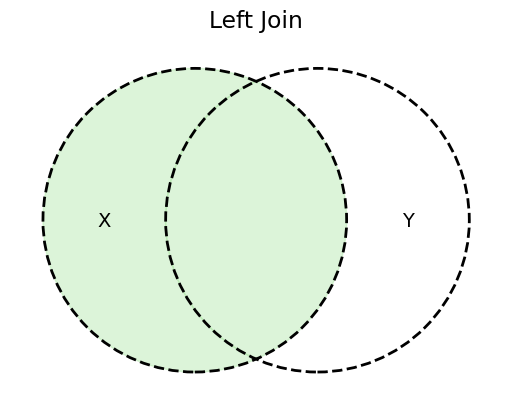

In [ ]:
# @title
plt.rcParams['font.size'] = '14'

# depict venn diagram
v = venn2(subsets=(1, 1, 1),
          set_labels=('', ''))
# set color to defined path id
v.get_patch_by_id("100").set_color("#a8e4a0")
v.get_patch_by_id("010").set_color("white")
v.get_patch_by_id("11").set_color("#a8e4a0")
# set text to defined label id "A"
# v.get_label_by_id('A').set_text('A new')

v.get_label_by_id("100").set_text("X")
v.get_label_by_id("010").set_text("Y")
v.get_label_by_id("11").set_text("")

# add outline
venn2_circles(subsets=(1, 1, 1),
              linestyle="dashed", linewidth=2)

# assign title
plt.title("Left Join")
plt.show()

In [ ]:
df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                    'B': ['B0', 'B1', 'B2']},
                     index=['K0', 'K1', 'K2'])

df2 = pd.DataFrame({'C': ['C0', 'C2', 'C3'],
                    'D': ['D0', 'D2', 'D3']},
                     index=['K0', 'K2', 'K3'])
display(df1, df2)

,A,B
K0,A0,B0
K1,A1,B1
K2,A2,B2


,C,D
K0,C0,D0
K2,C2,D2
K3,C3,D3


In [ ]:
result_left = pd.merge(df1, df2, left_index=True, right_index=True, how='left')
result_left

,A,B,C,D
K0,A0,B0,C0,D0
K1,A1,B1,NaN,NaN
K2,A2,B2,C2,D2


#### `how = 'right'`

In [ ]:
df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                    'B': ['B0', 'B1', 'B2']},
                     index=['K0', 'K1', 'K2'])

df2 = pd.DataFrame({'C': ['C0', 'C2', 'C3'],
                    'D': ['D0', 'D2', 'D3']},
                     index=['K0', 'K2', 'K3'])
display(df1, df2)

,A,B
K0,A0,B0
K1,A1,B1
K2,A2,B2


,C,D
K0,C0,D0
K2,C2,D2
K3,C3,D3


In [ ]:
result_left = pd.merge(df1, df2, left_index=True, right_index=True, how='right')
result_left

,A,B,C,D
K0,A0,B0,C0,D0
K2,A2,B2,C2,D2
K3,NaN,NaN,C3,D3


#### `how = 'outer'`

Берёт ключи из обоих датафреймов при создании нового.

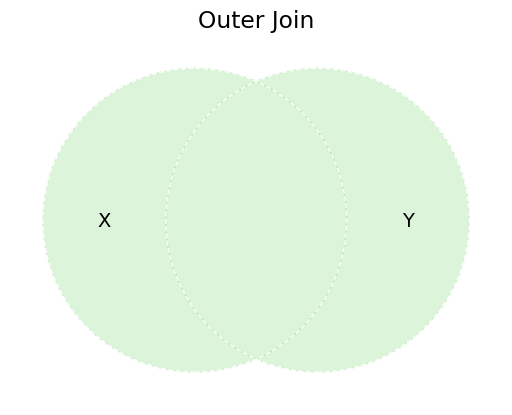

In [ ]:
# @title
plt.rcParams['font.size'] = '14'

# depict venn diagram
v = venn2(subsets=(1, 1, 1),
          set_labels=('', ''))
# set color to defined path id
v.get_patch_by_id("100").set_color("#a8e4a0")
v.get_patch_by_id("010").set_color("#a8e4a0")
v.get_patch_by_id("11").set_color("#a8e4a0")
# set text to defined label id "A"
# v.get_label_by_id('A').set_text('A new')

v.get_label_by_id("100").set_text("X")
v.get_label_by_id("010").set_text("Y")
v.get_label_by_id("11").set_text("")

# add outline
venn2_circles(subsets=(1, 1, 1),
              linestyle="dashed", linewidth=1, color = 'white')

# assign title
plt.title("Outer Join")
plt.show()

In [ ]:
df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                    'B': ['B0', 'B1', 'B2']},
                     index=['K0', 'K1', 'K2'])

df2 = pd.DataFrame({'C': ['C0', 'C2', 'C3'],
                    'D': ['D0', 'D2', 'D3']},
                     index=['K0', 'K2', 'K3'])
display(df1, df2)

,A,B
K0,A0,B0
K1,A1,B1
K2,A2,B2


,C,D
K0,C0,D0
K2,C2,D2
K3,C3,D3


In [ ]:
result_outer = pd.merge(df1, df2, left_index=True, right_index=True, how='outer')
result_outer

,A,B,C,D
K0,A0,B0,C0,D0
K1,A1,B1,NaN,NaN
K2,A2,B2,C2,D2
K3,NaN,NaN,C3,D3


### Варианты ключей (якорных признаков)

#### Индексы

In [ ]:
import pandas as pd

df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                    'B': ['B0', 'B1', 'B2']},
                     index=['K0', 'K1', 'K2'])

df2 = pd.DataFrame({'C': ['C0', 'C2', 'C3'],
                    'D': ['D0', 'D2', 'D3']},
                     index=['K0', 'K2', 'K3'])
display(df1, df2)

,A,B
K0,A0,B0
K1,A1,B1
K2,A2,B2


,C,D
K0,C0,D0
K2,C2,D2
K3,C3,D3


```pd.merge(датафрейм 1, датафрейм 2, left_index=True, right_index=True)```

In [ ]:
result = pd.merge(df1, df2, left_index=True, right_index=True)
result

,A,B,C,D
K0,A0,B0,C0,D0
K2,A2,B2,C2,D2


#### Индекс и колонка

In [ ]:
import pandas as pd

df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                    'B': ['B0', 'B1', 'B2']},
                     index=['K0', 'K1', 'K2'])

df2 = pd.DataFrame({'C': ['C0', 'C2', 'C3'],
                    'K': ['K0', 'K2', 'K3']},
                     index=['D0', 'D2', 'D3'])
display(df1, df2)

,A,B
K0,A0,B0
K1,A1,B1
K2,A2,B2


,C,K
D0,C0,K0
D2,C2,K2
D3,C3,K3


In [ ]:
result = pd.merge(df1, df2, left_index=True, right_on='K')
result

,A,B,C,K
D0,A0,B0,C0,K0
D2,A2,B2,C2,K2


In [ ]:
result = pd.merge(df2, df1, left_on='K', right_index=True)
result

,C,K,A,B
D0,C0,K0,A0,B0
D2,C2,K2,A2,B2


#### Колонки

In [ ]:
import pandas as pd

df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2'],
                    'B': ['B0', 'B1', 'B2']})

df2 = pd.DataFrame({'B': ['B0', 'B2', 'B3'],
                    'D': ['D0', 'D2', 'D3']})
display(df1, df2)

,A,B
0,A0,B0
1,A1,B1
2,A2,B2


,B,D
0,B0,D0
1,B2,D2
2,B3,D3


In [ ]:
result = pd.merge(df1, df2, left_on='B', right_on='B') #inner
result

,A,B,D
0,A0,B0,D0
1,A2,B2,D2
